
#  Global AI, Data Science & Tech Jobs: Analysis & Salary Prediction

The project involves analyzing a dataset with salary information for artificial intelligence (AI) and data jobs.
It icnludes several stages: from importing all needed libraries and dataset to machine learning model fitting and prediction on unseen data.

# 1 - Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# 2 - Dataset load and overview

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mohankrishnathalla/global-ai-and-data-jobs-salary-dataset/global_ai_jobs.csv")

print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

df.head()

Rows: 90000
Columns: 35


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000 non-null  object 
 14  weekly_hours          

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,45000.500000,7.028133,96546.249222,13028.418722,4.495689,2023.003200,45.476268,3.998004,17.521867,55.028604,...,19.986367,50.461200,50.357544,75.563533,57.198544,69.146478,38.439633,50.542411,1.503042,72.733100
std,25980.906451,5.889327,43935.479553,7886.738085,1.704553,2.002624,5.475497,0.461914,7.848576,17.901451,...,6.069607,28.853798,28.845671,11.316485,12.900225,13.213996,18.429221,28.891570,0.576449,8.124018
min,1.000000,0.000000,28000.000000,1404.000000,2.000000,2020.000000,36.000000,3.200000,1.000000,0.000000,...,10.000000,1.000000,1.000000,29.000000,25.000000,25.000000,12.000000,1.000000,0.500000,42.000000
25%,22500.750000,2.000000,64676.750000,7104.750000,3.000000,2021.000000,40.700000,3.600000,12.000000,42.881134,...,15.000000,25.000000,25.000000,68.000000,48.000000,59.000000,24.000000,25.000000,1.010000,67.000000
50%,45000.500000,6.000000,87544.000000,11279.000000,4.000000,2023.000000,45.500000,4.000000,17.000000,55.066089,...,20.000000,51.000000,50.000000,77.000000,57.000000,69.000000,37.000000,51.000000,1.510000,73.000000
75%,67500.250000,12.000000,123906.000000,16997.250000,6.000000,2025.000000,50.200000,4.400000,23.000000,67.118119,...,25.000000,75.000000,75.000000,84.000000,66.000000,79.000000,51.000000,76.000000,2.000000,78.000000
max,90000.000000,19.000000,300622.000000,57681.000000,7.000000,2026.000000,55.000000,4.800000,50.000000,100.000000,...,30.000000,100.000000,100.000000,99.000000,99.000000,98.000000,98.000000,100.000000,2.500000,99.000000


Most dataset features are numerical, only 8 of them are categorical (object type). We consider it since some machine learning models do not accept categorical data for learning, so that some transformation must be used, such as encoding. Depending on the type of feature (if the order is present or no), the different type of encoding will be used.

# 3 - Exploratory data analysis

### Salary distribution

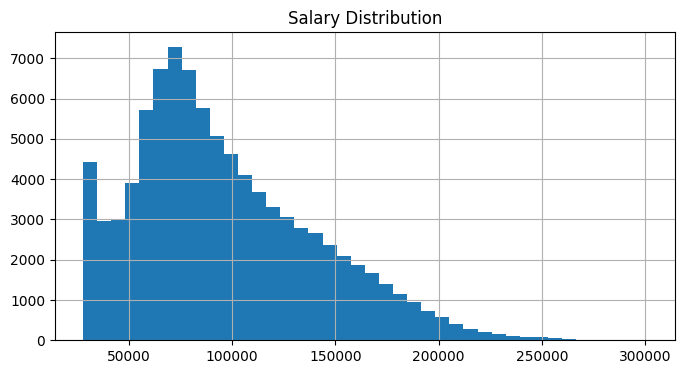

In [5]:
plt.figure(figsize=(8,4))
df["salary_usd"].hist(bins=40)
plt.title("Salary Distribution")
plt.show()

### Vacancies distribution by employee residence

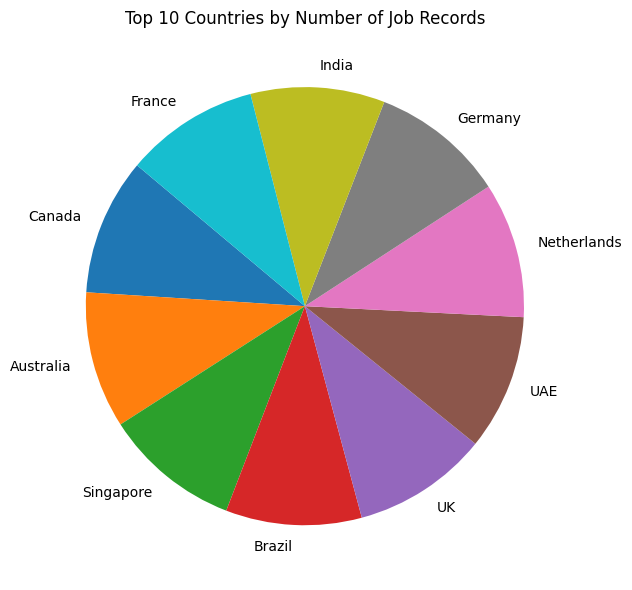

In [6]:
top_countries = df["country"].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.pie(
    top_countries.values,
    labels=top_countries.index,
    startangle=140
)


plt.title("Top 10 Countries by Number of Job Records")
plt.tight_layout()
plt.show()

### Salary Distribution by Experience Level

This plot represents the dependence between experience years and salary rate. Obviously we have that the more experinced an employee, the higher salary rate he/she has.

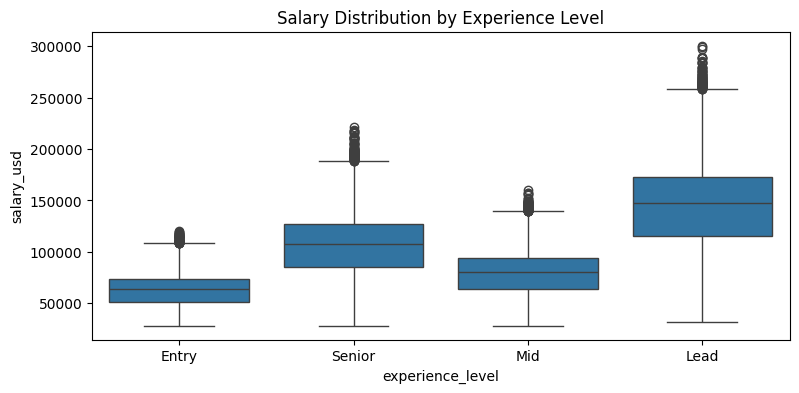

In [7]:
plt.figure(figsize=(9,4))
sns.boxplot(x="experience_level",y="salary_usd",data=df)
plt.title("Salary Distribution by Experience Level")
plt.show()

### Salary by job role

We can also check which positions in AI & Data get highest salaries by calculating average salary for each category. As a result, people with Engineering role (ML/CV/NLP/AI Engineers) have higher salary than Data analysts/scientists.

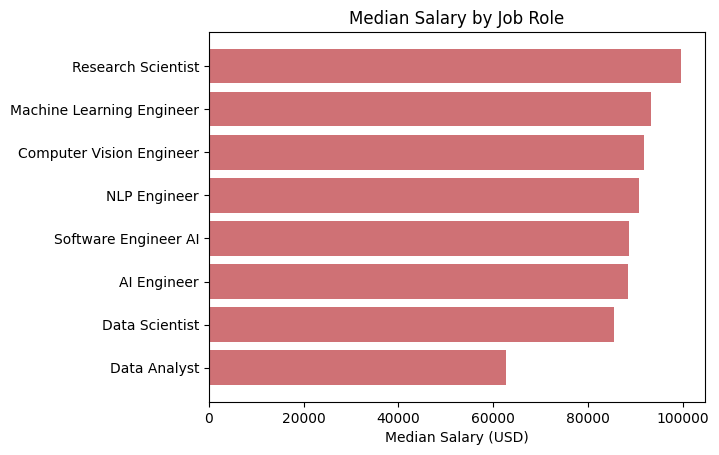

In [8]:
role_means = df.groupby("job_role")["salary_usd"].median().sort_values(ascending=True)
plt.barh(role_means.index, role_means.values, color="#C44E52", alpha=0.8)
plt.title("Median Salary by Job Role")
plt.xlabel("Median Salary (USD)")
plt.show()

We can also check whether work mode influences the salary rates, but it turns out that in general, it does not impact on the employee salary.

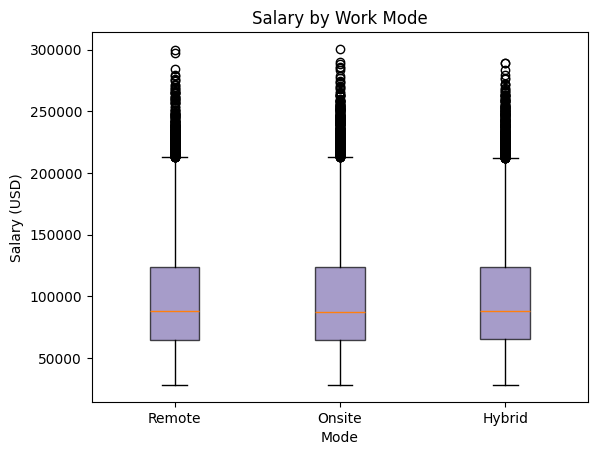

In [9]:
wm_data = [df[df["work_mode"] == w]["salary_usd"].values for w in df["work_mode"].unique()]
plt.boxplot(wm_data, labels=df["work_mode"].unique(), patch_artist=True,
                   boxprops=dict(facecolor="#8172B2", alpha=0.7))
plt.title("Salary by Work Mode")
plt.xlabel("Mode")
plt.ylabel("Salary (USD)")
plt.show()

# 4 - Feature engineering & data preparation

In [10]:
# Since salary_percentile feature is derived from salary, we should remove it from data before model fitting
LEAKY = ["id", "salary_percentile"]
df.drop(columns=LEAKY, inplace=True)

TARGET = "salary_usd"
y = df[TARGET]
X = df.drop(columns=[TARGET])

# Three features are ordinal, so we use ordinal encoding
EXP_ORDER  = [df['experience_level'].unique().tolist()]
EDU_ORDER  = [df['education_required'].unique().tolist()]
SIZE_ORDER = [df['company_size'].unique().tolist()]

oe_exp  = OrdinalEncoder(categories=EXP_ORDER)
oe_edu  = OrdinalEncoder(categories=EDU_ORDER)
oe_size = OrdinalEncoder(categories=SIZE_ORDER)

X["experience_level_enc"] = oe_exp.fit_transform(X[["experience_level"]])
X["education_enc"]        = oe_edu.fit_transform(X[["education_required"]])
X["company_size_enc"]     = oe_size.fit_transform(X[["company_size"]])
X.drop(columns=["experience_level", "education_required", "company_size"], inplace=True)

# One-hot encoding for the rest of categorical features
CAT_COLS = ["country", "job_role", "ai_specialization", "industry", "work_mode"]
X = pd.get_dummies(X, columns=CAT_COLS, drop_first=True)

# Bonus: sopme feature engineering
X["total_compensation"]       = y + df.get("bonus_usd", 0)   # note: y isn't yet split
X["comp_per_exp_year"]        = df["bonus_usd"] / (df["experience_years"].clip(lower=1))
X["funding_per_employee_est"] = df["company_funding_billion"] * 1e9 / (df["job_openings"].clip(lower=1))
X["demand_risk_ratio"]        = df["skill_demand_score"] / (df["automation_risk"].clip(lower=1))

print(f"\nFeature matrix shape after encoding: {X.shape}")


Feature matrix shape after encoding: (90000, 67)


In [11]:
# Checking the correlation between all features to remove that ones that have the highest value
corr = X.join(y).corr()["salary_usd"].abs().sort_values(ascending=False)
print(corr.head(15))

salary_usd               1.000000
total_compensation       0.994611
bonus_usd                0.752046
experience_years         0.723879
employee_satisfaction    0.629030
experience_level_enc     0.548241
layoff_risk              0.533439
job_security_score       0.434177
country_India            0.365403
comp_per_exp_year        0.303756
country_Brazil           0.294966
promotion_speed          0.261381
country_USA              0.248404
job_role_Data Analyst    0.231060
country_Singapore        0.140900
Name: salary_usd, dtype: float64


In [12]:
# total_compensation is calculated directly using salary_usd feature, so it should be removed 
X = X.drop(columns=['total_compensation'])

# 5 -  Splitting data into train and test

In [13]:
# 3.5 Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")

Train size: 72,000  |  Test size: 18,000


# 7 - Model training

In [15]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Fit, predict, and print metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    mape  = np.mean(np.abs((y_te - preds) / y_te.clip(lower=1))) * 100

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  MAE  : ${mae:>10,.0f}")
    print(f"  RMSE : ${rmse:>10,.0f}")
    print(f"  R²   :  {r2:.4f}")
    print(f"  MAPE :  {mape:.2f}%")

    return {"model": model, "preds": preds,
            "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape, "name": name}


results = {}

In [16]:
# Model 1: Ridge Regression
ridge = Ridge(alpha=10.0)
results["Ridge"] = evaluate("Ridge Regression (Baseline)",
                             ridge, X_train_sc, y_train, X_test_sc, y_test, scaled=True)


──────────────────────────────────────────────────
  Ridge Regression (Baseline)
──────────────────────────────────────────────────
  MAE  : $    10,251
  RMSE : $    13,189
  R²   :  0.9094
  MAPE :  12.66%


In [17]:
# Model 2: Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)
results["Random Forest"] = evaluate("Random Forest",
                                     rf, X_train, y_train, X_test, y_test)


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  MAE  : $     8,556
  RMSE : $    11,194
  R²   :  0.9348
  MAPE :  9.01%


# 8 - Models performance

In [18]:
metrics_df = pd.DataFrame([
    {"Model": k, "MAE": v["MAE"], "RMSE": v["RMSE"], "R²": v["R2"], "MAPE%": v["MAPE"]}
    for k, v in results.items()
]).set_index("Model")

print("\n\n" + "═"*55)
print("  MODEL COMPARISON")
print("═"*55)
print(metrics_df.to_string())
print("═"*55)

#fig, axes = plt.subplots(1, 2, figsize=(18, 5))
#fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

models_list = list(results.keys())
colors_bar  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]



═══════════════════════════════════════════════════════
  MODEL COMPARISON
═══════════════════════════════════════════════════════
                        MAE          RMSE        R²      MAPE%
Model                                                         
Ridge          10250.547529  13189.257272  0.909448  12.663577
Random Forest   8555.898286  11193.534387  0.934778   9.010214
═══════════════════════════════════════════════════════


### Test set

In [19]:
print("TEST SET PERFORMANCE")

for name, res in results.items():
    preds = res["preds"]
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    mape  = np.mean(np.abs((y_test - preds) / y_test.clip(lower=1))) * 100

    print(f"\n  {name}")
    print(f"  MAE  : ${mae:>10,.0f}")
    print(f"  RMSE : ${rmse:>10,.0f}")
    print(f"  R²   :  {r2:.4f}")
    print(f"  MAPE :  {mape:.2f}%")

TEST SET PERFORMANCE

  Ridge
  MAE  : $    10,251
  RMSE : $    13,189
  R²   :  0.9094
  MAPE :  12.66%

  Random Forest
  MAE  : $     8,556
  RMSE : $    11,194
  R²   :  0.9348
  MAPE :  9.01%


### Train vs test data comparison

In [20]:
rows = []

for name, res in results.items():
    model = res["model"]

    if name == "Ridge":
        train_preds = model.predict(X_train_sc)
        test_preds  = model.predict(X_test_sc)
    else:
        train_preds = model.predict(X_train)
        test_preds  = model.predict(X_test)

    for split, preds, y_true in [("Train", train_preds, y_train), ("Test", test_preds, y_test)]:
        rows.append({
            "Model":  name,
            "Split":  split,
            "MAE":    mean_absolute_error(y_true, preds),
            "RMSE":   np.sqrt(mean_squared_error(y_true, preds)),
            "R²":     r2_score(y_true, preds),
            "MAPE%":  np.mean(np.abs((y_true - preds) / y_true.clip(lower=1))) * 100
        })

summary = pd.DataFrame(rows).set_index(["Model", "Split"]).round(4)
print(summary.to_string())


                            MAE        RMSE      R²    MAPE%
Model         Split                                         
Ridge         Train  10208.5353  13140.6552  0.9107  12.4794
              Test   10250.5475  13189.2573  0.9094  12.6636
Random Forest Train   5173.6831   6954.4117  0.9750   5.4016
              Test    8555.8983  11193.5344  0.9348   9.0102


The results above show that the Random Forest model predicts significantly better than Ridge, with lower error metrics (MAE, RMSE, MAPE) and higher R² on both training and test sets. However, the gap between training and test data indicates some degree of overfitting. Ridge model demonstrates more consistent behaviour across both datasets, so it has stronger generalization but lower overall accuracy.

<b>Overall</b>: Random Forest is the better choice for prediction, while Ridge provides a more stable and interpretable case.
